# **LOAD DATASET**

In [9]:
import numpy as np
import pandas as pd

In [10]:
file_path = r"D:\Universitas Brawijaya_Roganda\BELAJAR_MANDIRI\DataScience\Project\StudentPerformanceFactors\dataset\Raw_StudentPerformanceFactors.csv"

df = pd.read_csv(file_path)

In [11]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [12]:
df.shape

(6607, 20)

In [13]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

# **DATASET VISUALIZATION**

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

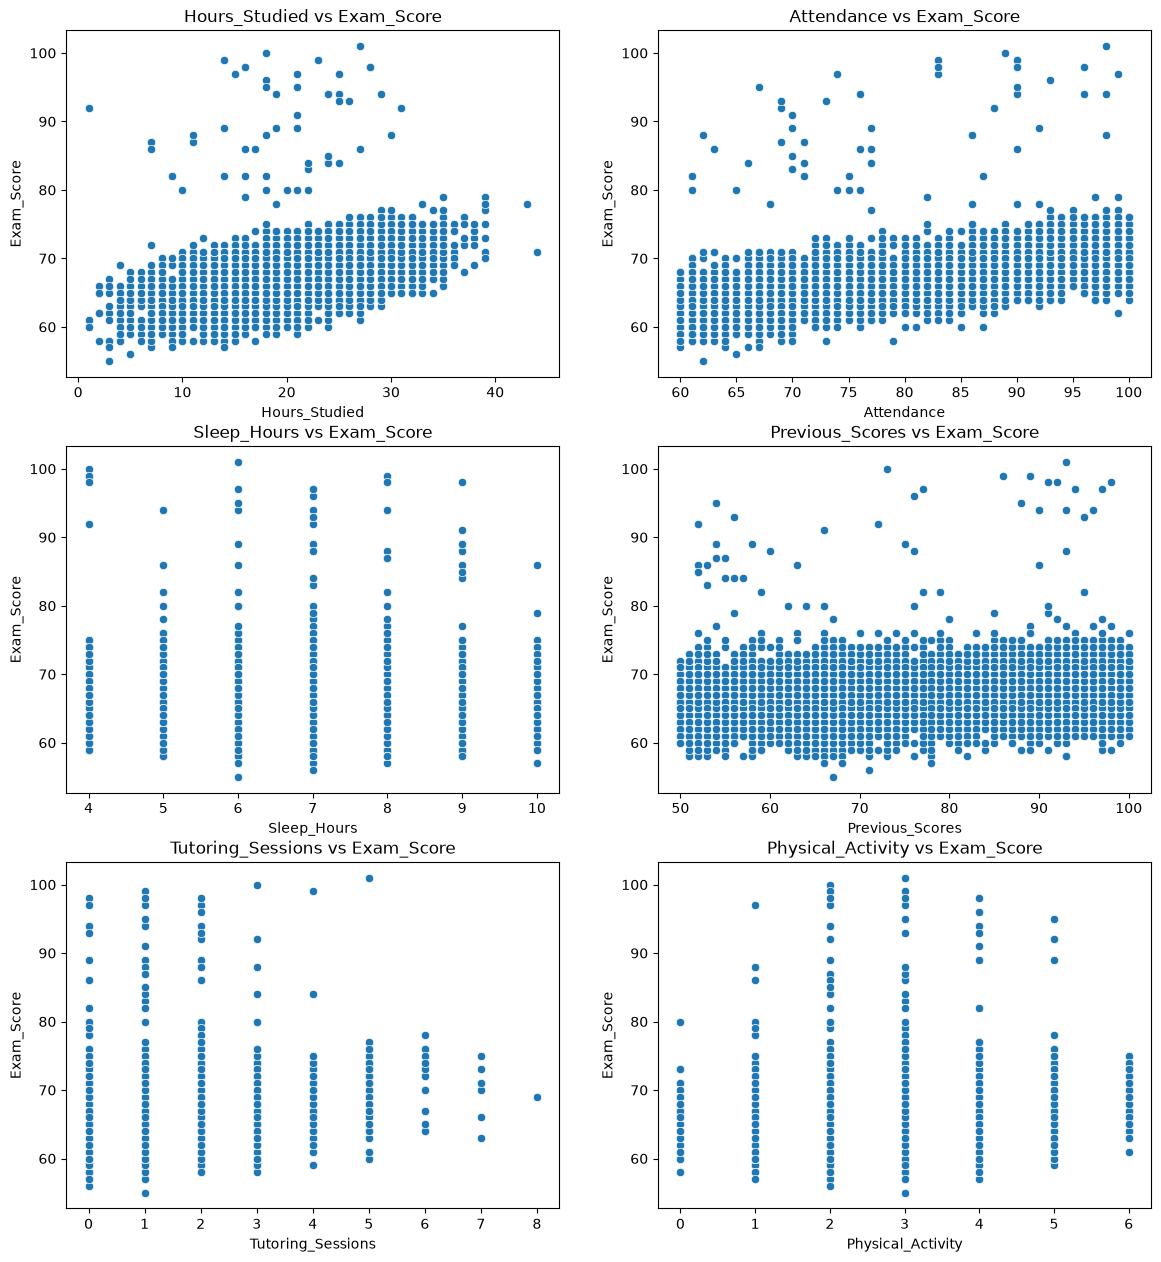

In [15]:
num_cols = df[
    [
        'Hours_Studied',
        'Attendance',
        'Sleep_Hours',
        'Previous_Scores',
        'Tutoring_Sessions',
        'Physical_Activity'
    ]
]

n_col = 2
n_row = -(-len(num_cols.columns) // n_col)


fig, axes = plt.subplots(n_row, n_col, figsize=(14, 5.1 * n_row))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(data=df, x=col, y='Exam_Score', ax=axes[i])
    axes[i].set_title(f'{col} vs Exam_Score')

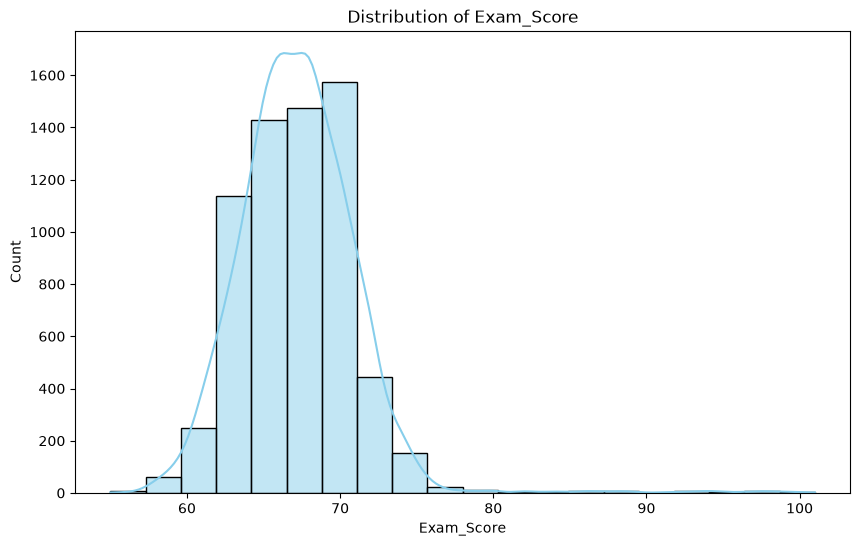

In [16]:
# Histogram of Exam_Score
plt.figure(figsize=(10, 6))
sns.histplot(df['Exam_Score'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Exam_Score')
plt.xlabel('Exam_Score')
plt.show()

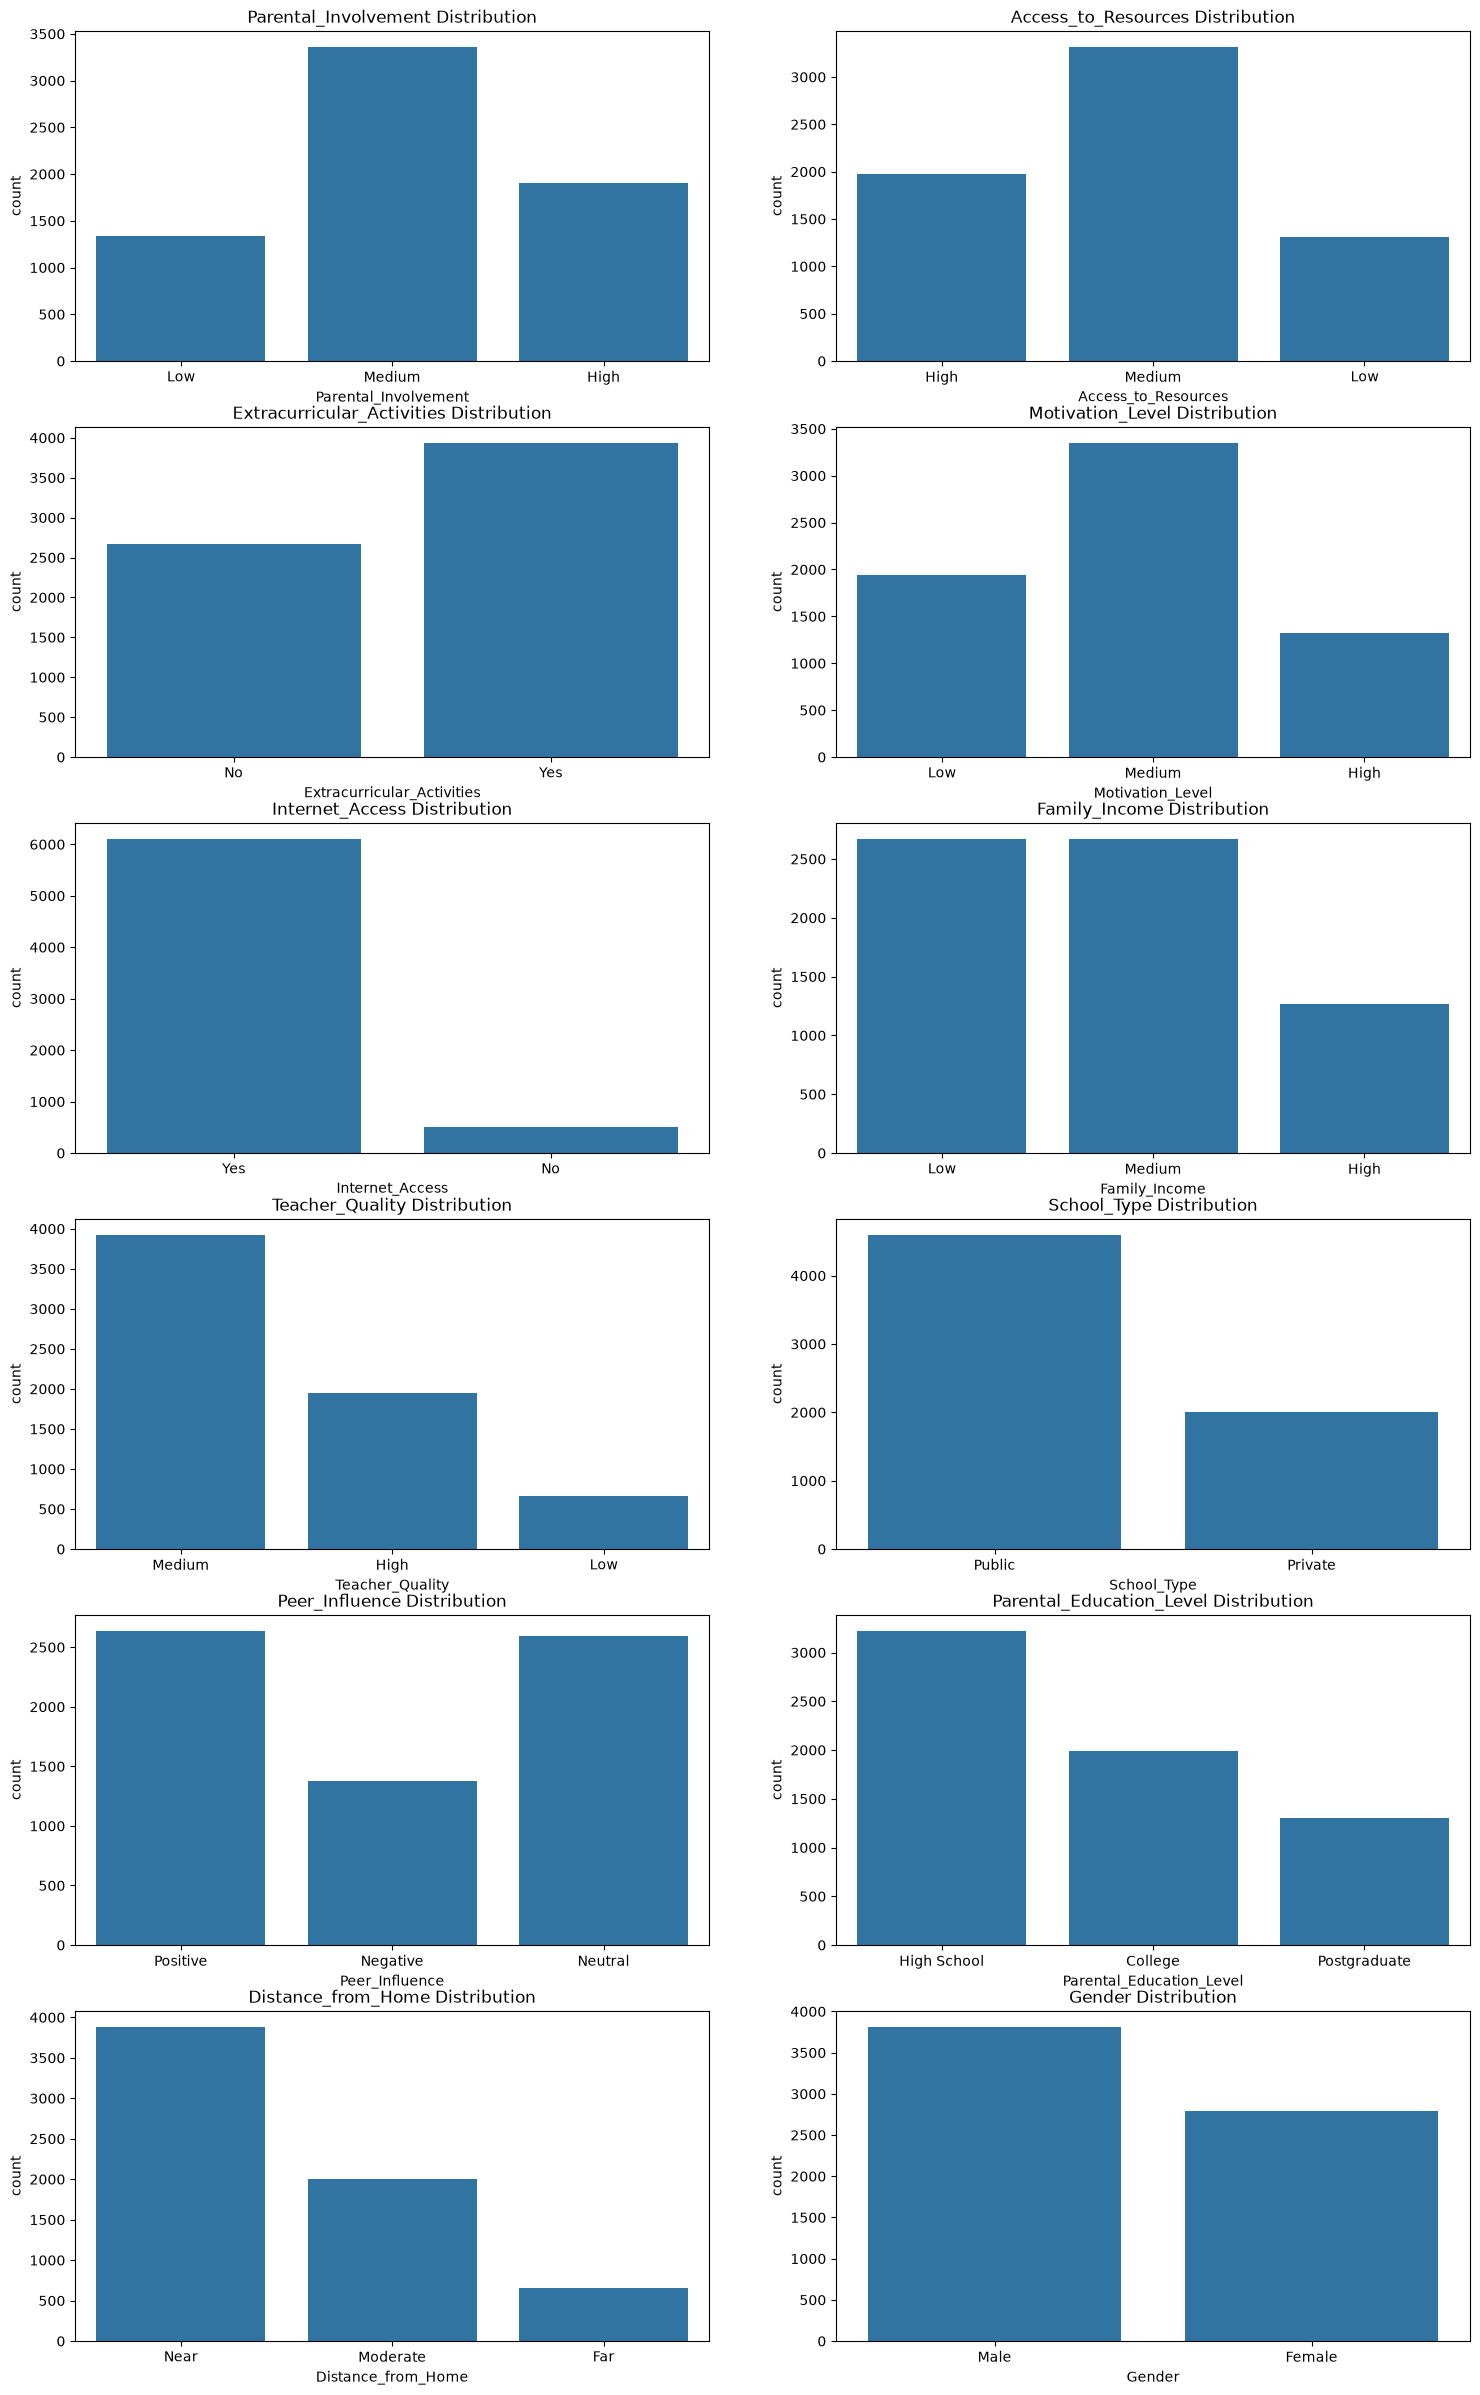

In [17]:
categ_cols = df[
    [
        'Parental_Involvement',
        'Access_to_Resources',
        'Extracurricular_Activities',
        'Motivation_Level',
        'Internet_Access',
        'Family_Income',
        'Teacher_Quality',
        'School_Type',
        'Peer_Influence',
        'Parental_Education_Level',
        'Distance_from_Home',
        'Gender'
    ]
]

n_col = 2
n_row = -(-len(categ_cols.columns) // n_col)


fig, axes = plt.subplots(n_row, n_col, figsize=(18, 5 * n_row))
axes = axes.flatten()

for i, col in enumerate(categ_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')

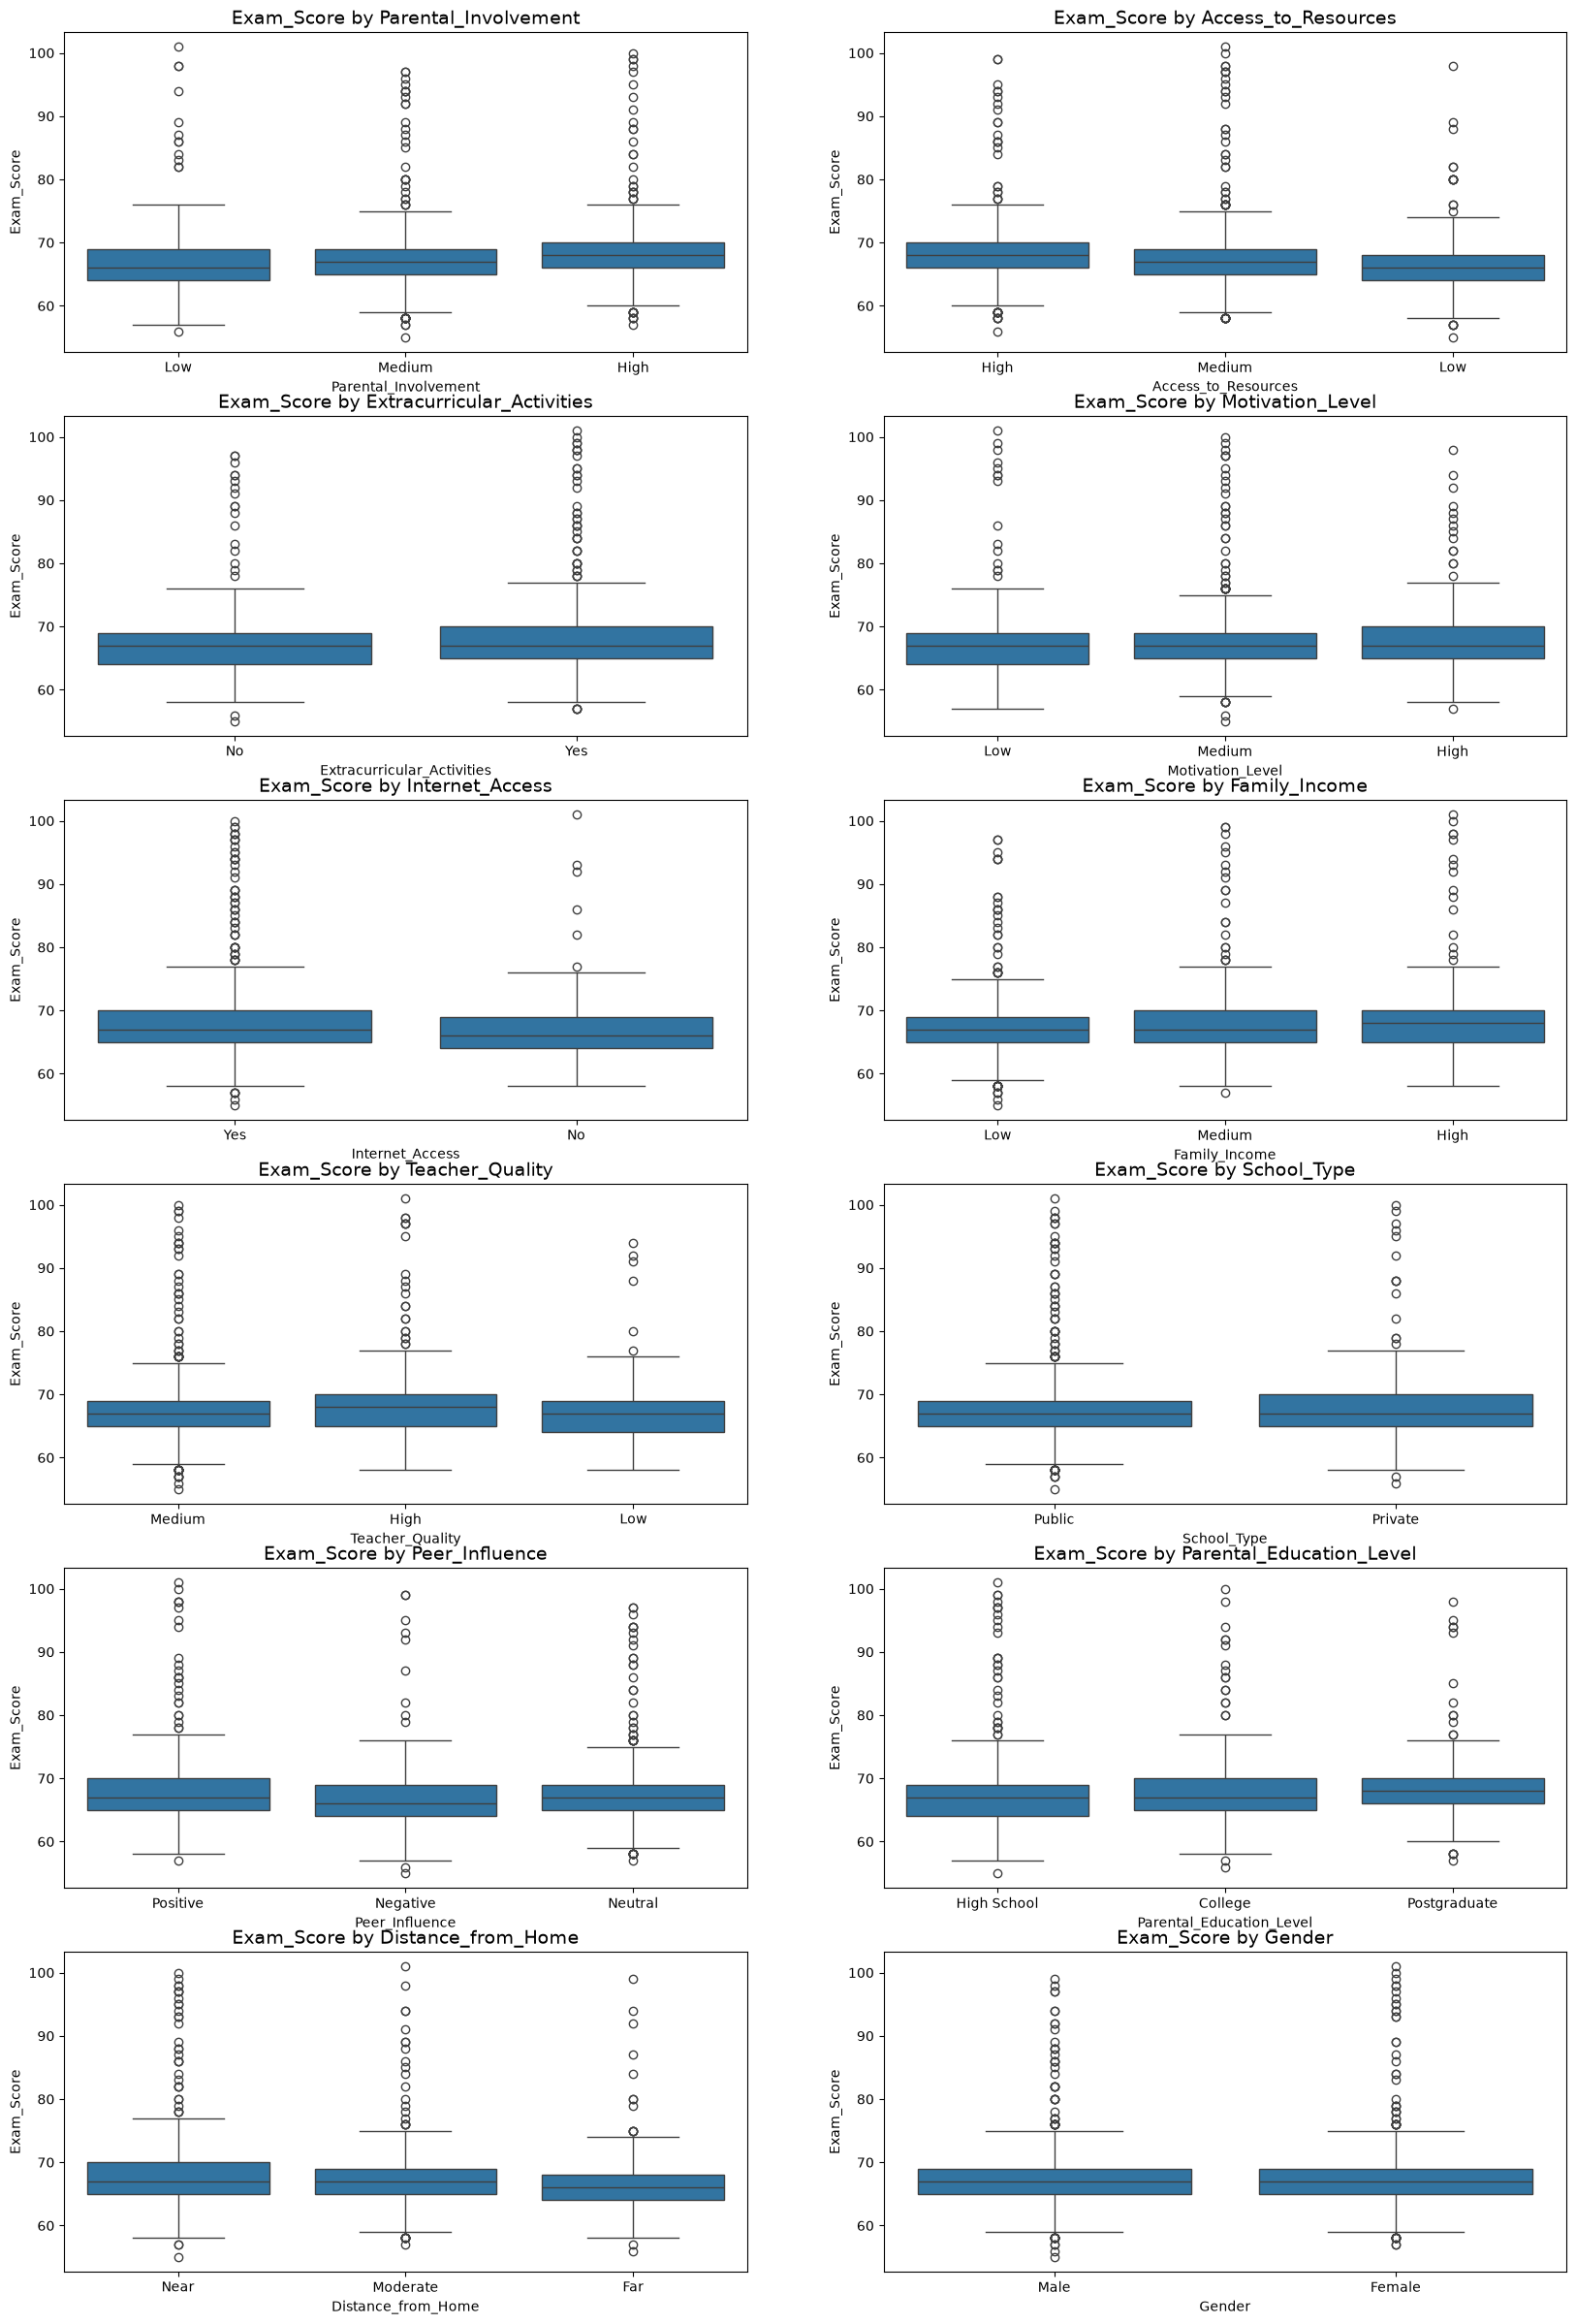

In [18]:
n_col = 2
n_row = -(-len(categ_cols.columns) // n_col)


fig, axes = plt.subplots(n_row, n_col, figsize=(20, 5 * n_row))
axes = axes.flatten()

for i, col in enumerate(categ_cols):
    sns.boxplot(data=df, x=col, y='Exam_Score', ax=axes[i])
    axes[i].set_title(f'Exam_Score by {col}', fontsize=14)

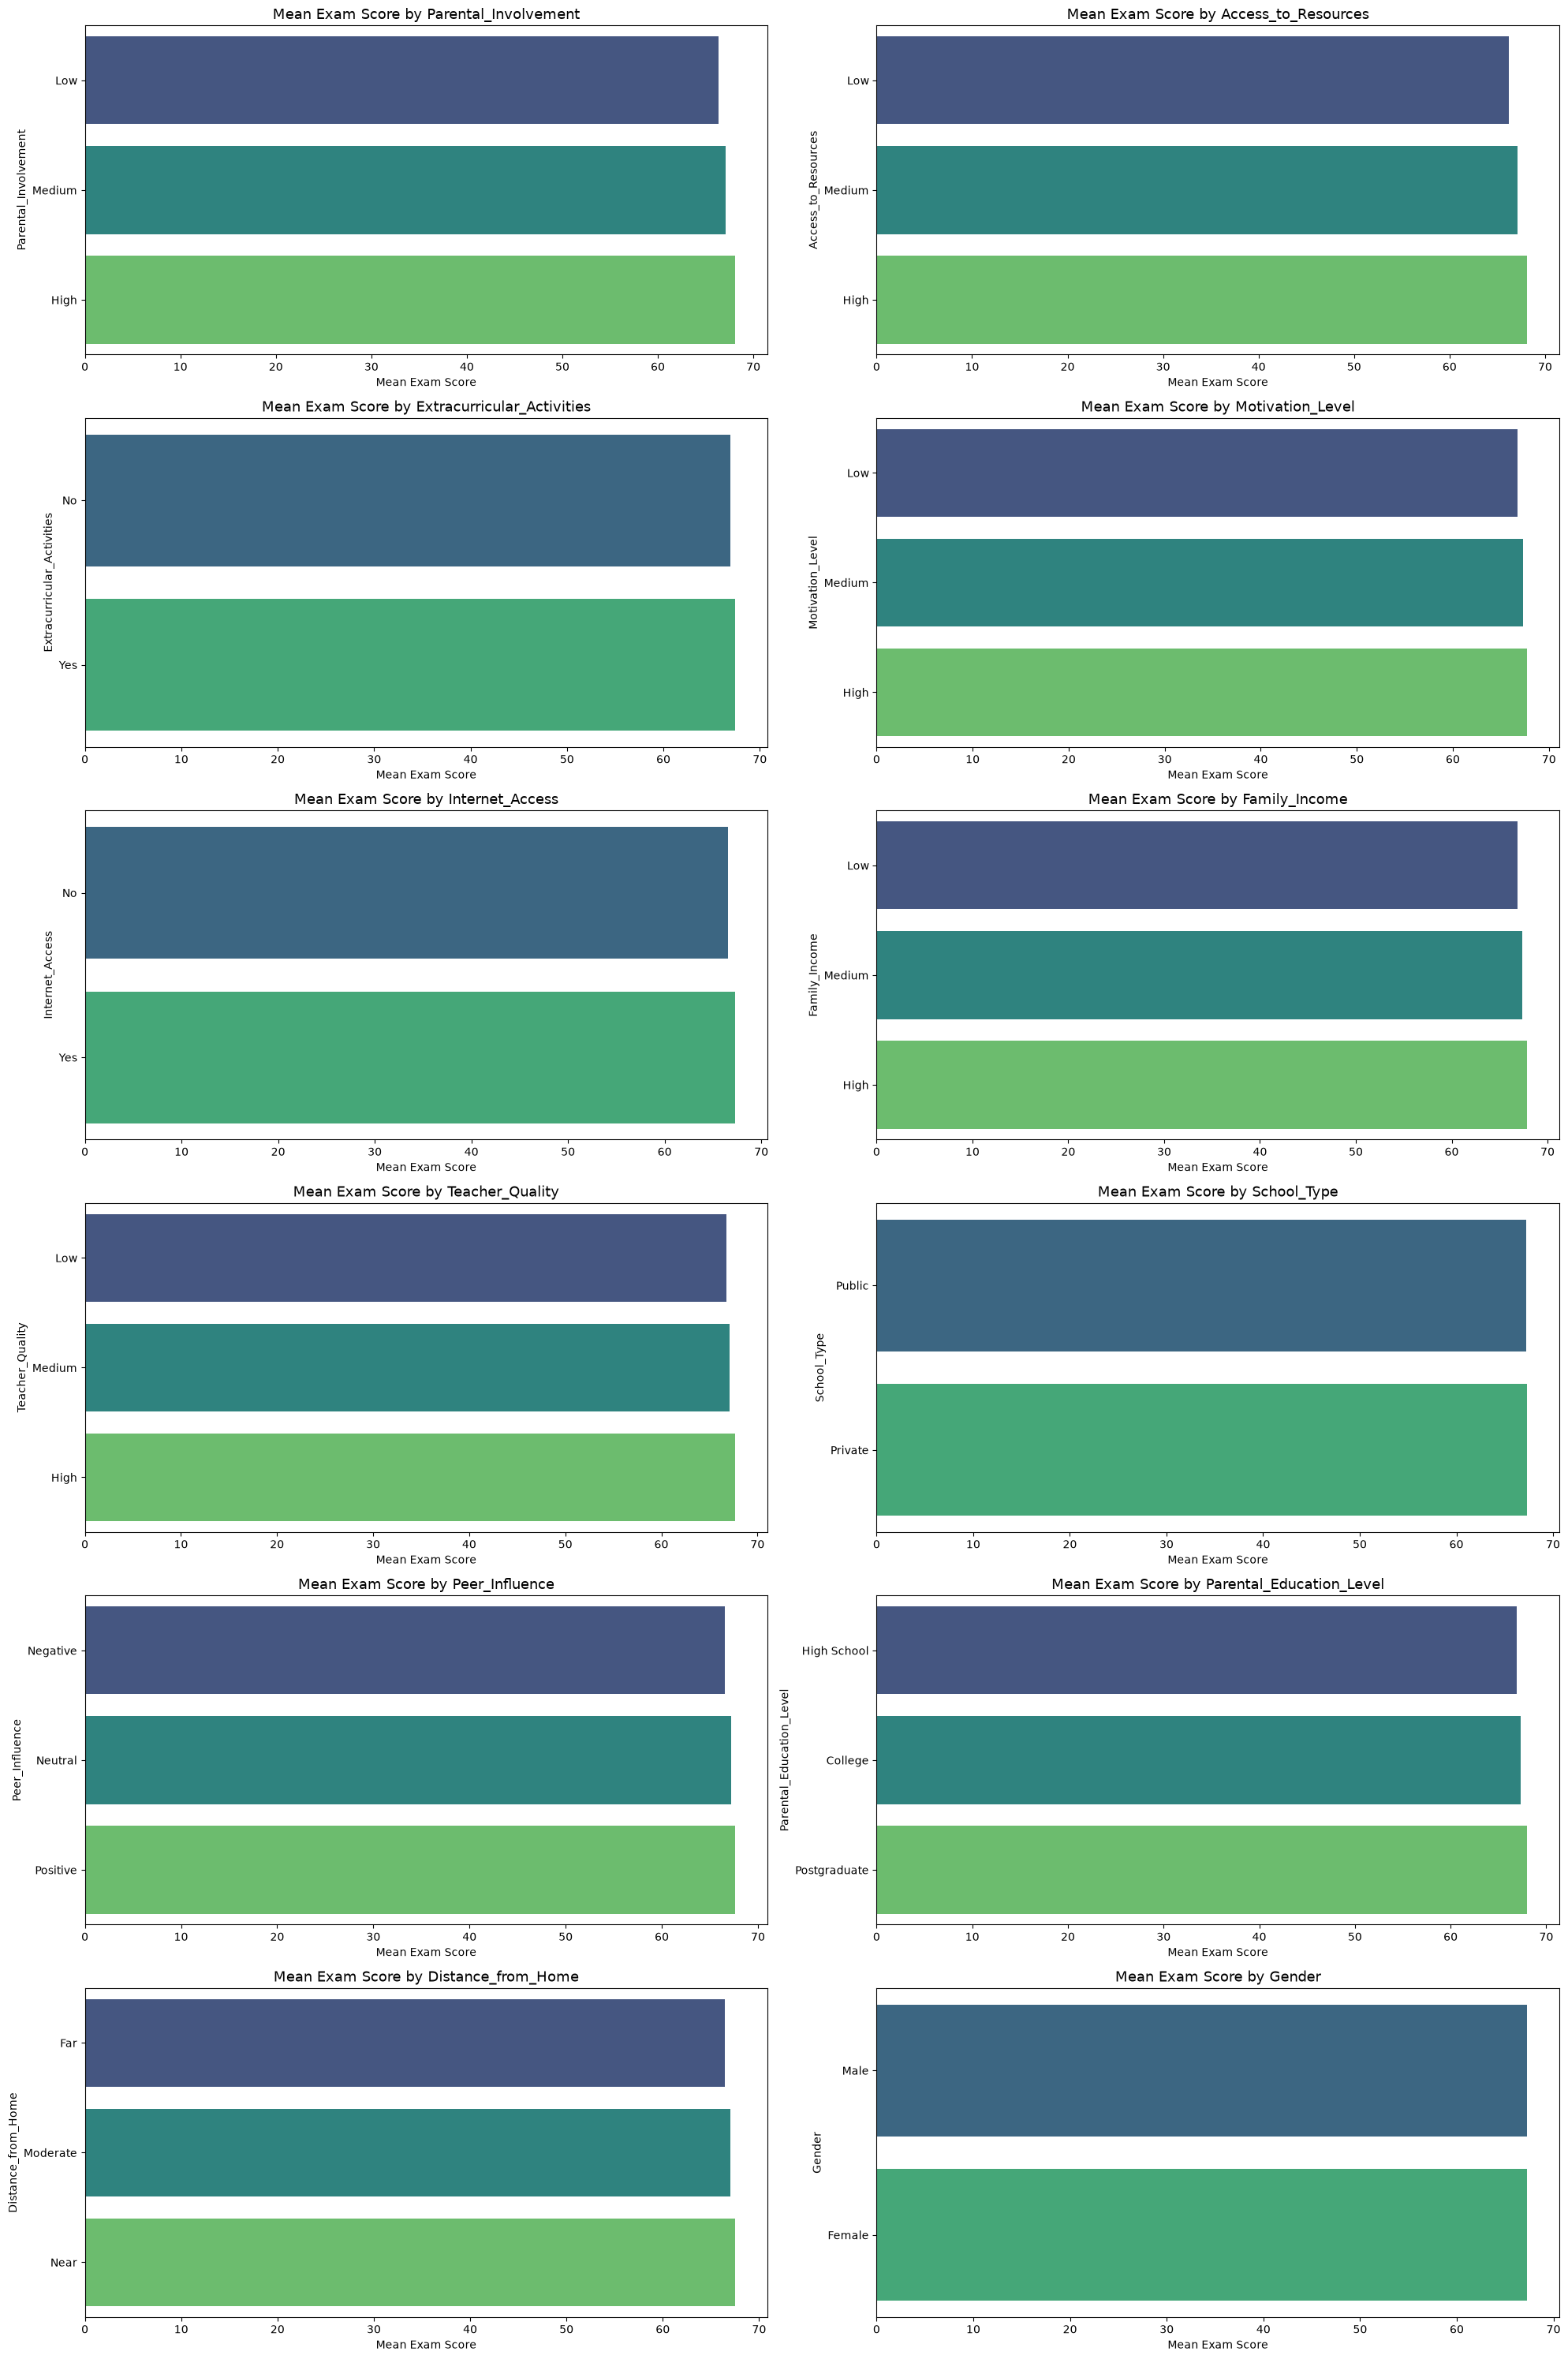

In [19]:
n_col = 2
n_row = -(-len(categ_cols.columns) // n_col)

fig, axes = plt.subplots(
    n_row,
    n_col,
    figsize=(20, 5 * n_row)
)

axes = axes.flatten()

for i, col in enumerate(categ_cols):
    mean_scores = ( df.groupby(col)['Exam_Score'].mean().sort_values())

    sns.barplot(x=mean_scores.values,y=mean_scores.index,hue=mean_scores.index,palette='viridis',legend=False,ax=axes[i])

    axes[i].set_title(f'Mean Exam Score by {col}',fontsize=13,)

    axes[i].set_xlabel('Mean Exam Score')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# **PROCESSING I**

## Check Missing Value

In [20]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## Check Duplicated Value

In [21]:
df[df.duplicated()]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score


## Check By Colomns

In [22]:
df.duplicated().sum()

np.int64(0)

### Hours Studied

In [23]:
df['Hours_Studied'].describe()

count    6607.000000
mean       19.975329
std         5.990594
min         1.000000
25%        16.000000
50%        20.000000
75%        24.000000
max        44.000000
Name: Hours_Studied, dtype: float64

In [24]:
df['Hours_Studied'].unique()

array([23, 19, 24, 29, 25, 17, 21,  9, 10, 14, 22, 15, 12, 20, 11, 13, 16,
       18, 31,  8, 26, 28,  4, 35, 27, 33, 36, 43, 34,  1, 30,  7, 32,  6,
       38,  5,  3,  2, 39, 37, 44])

### Attendance

In [25]:
df['Attendance'].describe()

count    6607.000000
mean       79.977448
std        11.547475
min        60.000000
25%        70.000000
50%        80.000000
75%        90.000000
max       100.000000
Name: Attendance, dtype: float64

### Parental Involvement

In [26]:
df['Parental_Involvement'].value_counts()

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

### Access To Resources

In [27]:
df["Access_to_Resources"].value_counts()

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

### Extracurricular Activities

In [28]:
df['Extracurricular_Activities'].value_counts()

Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

### Sleep Hours

In [29]:
df['Sleep_Hours'].describe()

count    6607.00000
mean        7.02906
std         1.46812
min         4.00000
25%         6.00000
50%         7.00000
75%         8.00000
max        10.00000
Name: Sleep_Hours, dtype: float64

In [30]:
df['Sleep_Hours'].value_counts()

Sleep_Hours
7     1741
8     1399
6     1376
9      775
5      695
10     312
4      309
Name: count, dtype: int64

### Previous Scores

In [31]:
df['Previous_Scores'].describe()

count    6607.000000
mean       75.070531
std        14.399784
min        50.000000
25%        63.000000
50%        75.000000
75%        88.000000
max       100.000000
Name: Previous_Scores, dtype: float64

In [32]:
df['Previous_Scores'].value_counts()

Previous_Scores
66     165
94     155
96     153
85     150
71     146
53     144
59     142
82     141
76     140
88     139
73     138
86     137
91     136
65     136
70     136
54     136
52     136
63     135
74     134
67     134
80     133
68     132
75     132
64     132
98     131
89     130
78     130
93     129
69     129
95     129
79     128
51     126
92     126
99     125
57     125
83     125
87     124
81     124
62     124
55     124
90     123
61     123
77     122
84     121
60     121
72     120
58     120
56     120
97     115
100     69
50      62
Name: count, dtype: int64

### Motivation Level

In [33]:
df['Motivation_Level'].value_counts()

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

### Internet Access

In [34]:
df["Internet_Access"].value_counts()

Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

### Tutoring Sessions

In [35]:
df['Tutoring_Sessions'].describe()

count    6607.000000
mean        1.493719
std         1.230570
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         8.000000
Name: Tutoring_Sessions, dtype: float64

In [36]:
df['Tutoring_Sessions'].value_counts()

Tutoring_Sessions
1    2179
2    1649
0    1513
3     836
4     301
5     103
6      18
7       7
8       1
Name: count, dtype: int64

In [37]:
df[df['Tutoring_Sessions'] == 8]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
2231,25,72,Low,Low,Yes,6,78,Low,Yes,8,Medium,High,Public,Positive,4,No,High School,Near,Male,69


### Family Income

In [38]:
df['Family_Income'].value_counts()

Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

### Teacher Quality

In [39]:
df['Teacher_Quality'].value_counts()

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

In [40]:
# Check IQR For Fill Missing Values
Q1 = df['Exam_Score'].quantile(0.25)
Q3 = df['Exam_Score'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")

df['Exam_Score'].describe()

Q1: 65.0, Q3: 69.0, IQR: 4.0


count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [41]:
df.loc[df['Teacher_Quality'].isnull() & (df['Exam_Score'] > 69), 'Teacher_Quality'] = 'High'

df.loc[df['Teacher_Quality'].isnull() & (df['Exam_Score'] > 65) & (df['Exam_Score'] <= 69), 'Teacher_Quality'] = 'Medium'

df.loc[df['Teacher_Quality'].isnull() & (df['Exam_Score'] <= 65), 'Teacher_Quality'] = 'Low'

In [42]:
df['Teacher_Quality'].isnull().sum()

np.int64(0)

### School Type

In [43]:
df['School_Type'].value_counts()

School_Type
Public     4598
Private    2009
Name: count, dtype: int64

### Peer Influence

In [44]:
df['Peer_Influence'].value_counts()

Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

### Physical Activity

In [45]:
df['Physical_Activity'].describe()

count    6607.000000
mean        2.967610
std         1.031231
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: Physical_Activity, dtype: float64

In [46]:
df['Physical_Activity'].value_counts()

Physical_Activity
3    2545
2    1627
4    1575
1     421
5     361
0      46
6      32
Name: count, dtype: int64

### Learning Disabilities

In [47]:
df['Learning_Disabilities'].value_counts()

Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64

### Parental Education

In [48]:
df['Parental_Education_Level'].value_counts()

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

In [49]:
df['Parental_Education_Level'].isnull().sum()

np.int64(90)

In [50]:
df[df['Parental_Education_Level'].isnull()]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
240,15,87,Low,Medium,No,4,54,Medium,Yes,1,Medium,Medium,Public,Neutral,6,No,NaN,Moderate,Male,65
408,21,65,High,High,No,7,88,Low,Yes,2,Low,Medium,Private,Neutral,1,No,NaN,Near,Male,65
417,21,91,High,Medium,No,9,74,Medium,Yes,2,Low,Low,Private,Negative,2,No,NaN,Near,Female,69
451,26,94,High,Medium,Yes,10,54,Low,Yes,2,High,Medium,Public,Neutral,5,No,NaN,Near,Male,73
592,23,85,High,Low,Yes,6,59,Low,Yes,1,Medium,Medium,Public,Negative,1,No,NaN,Near,Male,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6253,22,85,High,Medium,Yes,6,96,Medium,Yes,0,Low,Medium,Public,Neutral,3,No,NaN,Moderate,Female,69
6323,28,72,Low,High,No,8,63,Low,Yes,1,Low,High,Public,Neutral,2,No,NaN,Near,Male,66
6411,19,92,High,Medium,No,6,70,High,Yes,2,Medium,Medium,Private,Negative,3,No,NaN,Near,Female,71
6423,21,70,Medium,High,Yes,5,62,Medium,Yes,2,Low,High,Public,Neutral,2,No,NaN,Near,Female,66


In [51]:
df.loc[df['Parental_Education_Level'].isnull() & (df['Exam_Score'] > 69), 'Parental_Education_Level'] = 'Postgraduate'

df.loc[df['Parental_Education_Level'].isnull() & (df['Exam_Score'] > 65) & (df['Exam_Score'] <= 69), 'Parental_Education_Level'] = 'College'

df.loc[df['Parental_Education_Level'].isnull() & (df['Exam_Score'] <= 65), 'Parental_Education_Level'] = 'High School'

In [52]:
df['Parental_Education_Level'].value_counts()

Parental_Education_Level
High School     3258
College         2022
Postgraduate    1327
Name: count, dtype: int64

In [53]:
df['Parental_Education_Level'].isnull().sum()

np.int64(0)

### Distance From Home

In [54]:
df['Distance_from_Home'].value_counts()

Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64

In [55]:
df.loc[df['Distance_from_Home'].isnull() & (df['Exam_Score'] > 69), 'Distance_from_Home'] = 'Near'

df.loc[df['Distance_from_Home'].isnull() & (df['Exam_Score'] > 65) & (df['Exam_Score'] <= 69), 'Distance_from_Home'] = 'Moderate'

df.loc[df['Distance_from_Home'].isnull() & (df['Exam_Score'] <= 65), 'Distance_from_Home'] = 'Far'

In [56]:
df['Distance_from_Home'].isnull().sum()

np.int64(0)

### Gender

In [57]:
df['Gender'].value_counts()

Gender
Male      3814
Female    2793
Name: count, dtype: int64

### Exam Score

In [58]:
df['Exam_Score'].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

In [59]:
df.loc[df['Exam_Score'] == 101, 'Exam_Score'] = 100

In [60]:
df['Exam_Score'].describe()

count    6607.000000
mean       67.235508
std         3.889161
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       100.000000
Name: Exam_Score, dtype: float64

# SAVE NEW DATASET AS NEW CSV

In [61]:
# I have runned the code, so i make it as comment

# df.to_csv('dataset\Cleaned_StudentPerformanceFactors.csv', index=False)